In [1]:
import os
os.environ['OMP_NUM_THREADS']      = '1'
os.environ['MKL_NUM_THREADS']      = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'

In [15]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pickle
import matplotlib.pyplot as plt
import sys
sys.path.append('../..')
sys.path.append('../../results')

from fig5.fig5_functions import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# --- Load Ws to get ensemble sizes for splitting results ---
# Download from Zenodo [DOI] and place under data/fig2/
data_root = '../../data/fig2'
sigmas    = ['sigma02', 'sigma05', 'sigma1']

data = []
for s in sigmas:
    with open(f'{data_root}/{s}/Ws.pkl', 'rb') as f:
        data.append(pickle.load(f))

solutions = [[d for d in ds if not np.all(d.get('W') == 0)] for ds in data]
matrices  = [[d['W']      for d in s] for s in solutions]
lambdas   = [[d['Lambda'] for d in s] for s in solutions]

n0, n1 = len(matrices[0]), len(matrices[1])

In [5]:
with open('../../data/fig5/pseudospectrum_analysis.pkl', 'rb') as f:
    results = pickle.load(f)

res0 = results[:n0]
res1 = results[n0:n0 + n1]
res2 = results[n0 + n1:]

In [6]:
# --- Extract r_stab and G_max per ensemble ---
def extract_rstab_Gmax(res_list):
    r_stab = np.array([r['r_stab'] for r in res_list])
    G_max  = np.array([r['G_max']  for r in res_list])
    return r_stab, G_max

r0, g0 = extract_rstab_Gmax(res0)
r1, g1 = extract_rstab_Gmax(res1)
r2, g2 = extract_rstab_Gmax(res2)

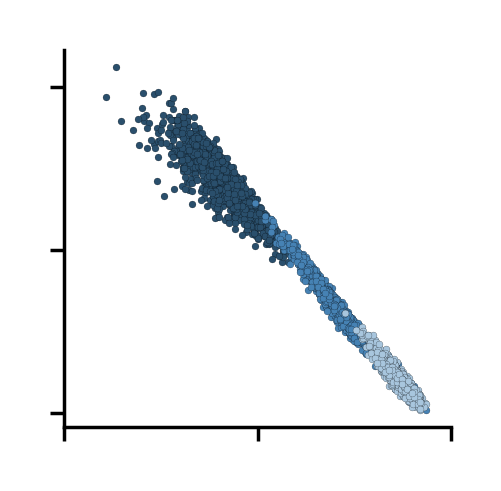

In [7]:
# --- MAIN: r_stab vs G_max scatter ---
fig, ax = plt.subplots(figsize=(1, 1), dpi=500)

ax.scatter(r0, g0, s=1, alpha=1, color='#2a4f6c', edgecolor='k', linewidth=0.03)
ax.scatter(r1, g1, s=1, alpha=1, color='#4682B4', edgecolor='k', linewidth=0.03)
ax.scatter(r2, g2, s=1, alpha=1, color='#a8c6de', edgecolor='k', linewidth=0.03)

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xticks([1e-11, 1e-6, 1e-1]); ax.set_xticklabels([])
ax.set_yticks([1e1, 1e4, 1e7]);      ax.set_yticklabels([])
ax.spines['top'].set_visible(False);  ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5); ax.spines['bottom'].set_linewidth(0.5)
ax.tick_params(length=2, width=0.5)
plt.show()

In [8]:
# --- Select most fragile and most robust matrices ---
all_Js = matrices[0] + matrices[1] + matrices[2]
all_Ls = lambdas[0]  + lambdas[1]  + lambdas[2]
r_stabs = np.array([r['r_stab'] for r in results])

idx_fragile = int(np.argmin(r_stabs))
idx_robust  = int(np.argmax(r_stabs))

# Convert J -> M = J - I for pseudospectrum
J_fragile = all_Js[idx_fragile] - np.eye(100)
J_robust  = all_Js[idx_robust]  - np.eye(100)
L_fragile = np.asarray(all_Ls[idx_fragile]) - 1
L_robust  = np.asarray(all_Ls[idx_robust])  - 1

In [9]:
# --- Compute pseudospectra ---
X_fragile, Y_fragile, sm_fragile = compute_pseudospectrum_grid(J_fragile, grid_points=120, xy_lim=4)
X_robust,  Y_robust,  sm_robust  = compute_pseudospectrum_grid(J_robust,  grid_points=120, xy_lim=4)

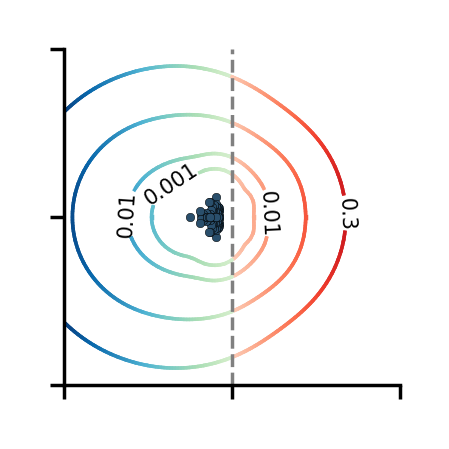

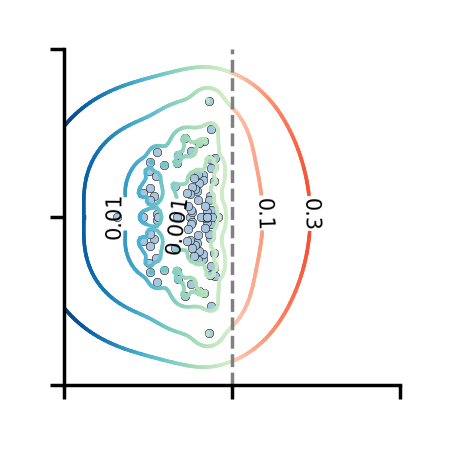

In [10]:
# --- MAIN: pseudospectrum plots ---
plot_pseudospectrum(X_fragile, Y_fragile, sm_fragile, L_fragile,
                    eps_levels=(1e-3, 1e-2, 1e-1, 0.3),
                    xy_lim=4, color_eigs='#2a4f6c')
plt.show()

plot_pseudospectrum(X_robust, Y_robust, sm_robust, L_robust,
                    eps_levels=(1e-3, 1e-2, 1e-1, 0.3),
                    xy_lim=4, color_eigs='#a8c6de')
plt.show()

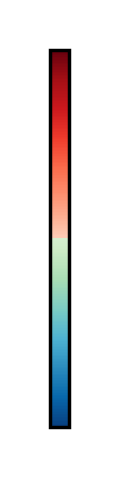

(<Figure size 25x500 with 1 Axes>, <Axes: >)

In [11]:
# --- Colorbar for pseudospectrum coloring ---
plot_signed_distance_colorbar(x_scale=4)

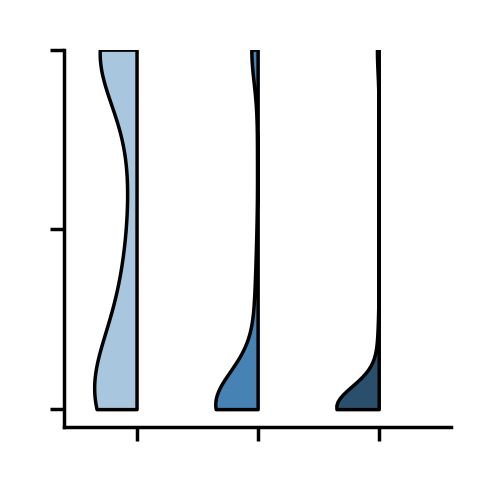

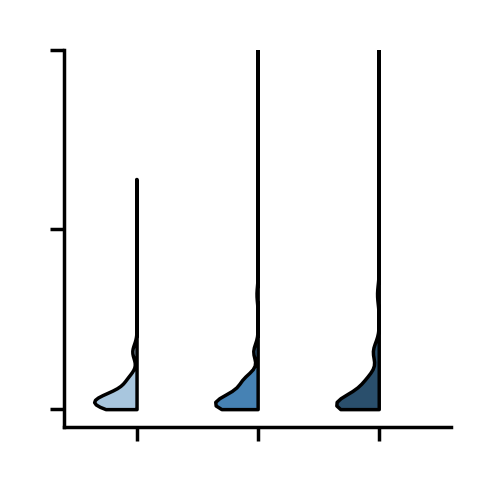

(<Figure size 500x500 with 1 Axes>, <Axes: >)

In [13]:
with open('../../data/fig5/robustness.pkl', 'rb') as f:
    robustness_results = pickle.load(f)
    
# --- MAIN: robustness violin plots ---
violin_fraction_x0_capped_by_ensemble(robustness_results)
violin_eta_dyn_by_ensemble(robustness_results)

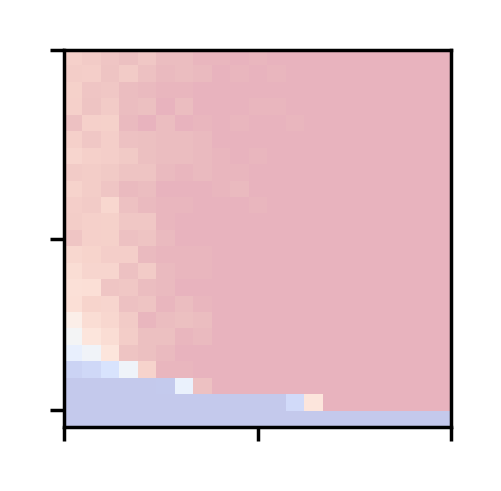

/Users/ncondruz/Desktop/PATNs/results/fig5/../../results/fig5/fig5_functions.py:326: UserWarning: Adding colorbar to a different Figure <Figure size 500x500 with 1 Axes> than <Figure size 25x500 with 1 Axes> which fig.colorbar is called on.
  cbar = fig_cb.colorbar(im, cax=ax_cb, orientation='vertical')


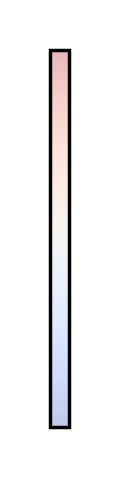

In [16]:
with open('../../data/fig5/rob1144_half.pkl', 'rb') as f:
    p_hat, counts, baseline_rate = pickle.load(f)
    
# --- MAIN: volcano heatmap ---
radii   = [0.01, 0.025, 0.05] + list(np.arange(0.1, 2.0 + 1e-12, 0.1))
cosines = list(np.round(np.arange(0, 1.0 + 1e-12, 0.05), 10))
plot_success_heatmap(p_hat, radii, cosines)